# Which branch of each segment's tree moved, and how much less did each Retail-Plus member spend?

**Week 2, Monday. Chapter 4 of 6.** Chapter 3 put each segment's leaves on their own rows;
this chapter sets Q1 beside Q2 for every branch in one query, and prices the fall per member.

> "How much less is each of my members spending, and is it fewer members buying or each one
> buying less?"
> The head of Retail-Plus, Kalpa Retail

**Who needs the answer.** Anand's analyst wants the quarter comparison as one query that reads
from top to bottom, and the head of Retail-Plus decides how hard to work to keep the tier's
members. An average that quietly leaves out the members who stopped buying says the tier's
spend per member fell 15.5 percent when it fell 29.4, and says Retail-Core and Business members
spent more when they spent less. The tier would get a light touch while it lost nearly a third
of its spend.

**The questions on the way.**
1. Nested subqueries, named steps or temporary tables?
2. How did customers, frequency and order value move in each segment?
3. How much less did each Retail-Plus member spend?
4. Does a member count taken from the customer table give the same change?

**The metric at stake.** Each branch of the tree as a ratio, Q2 over Q1: customers who bought,
orders per customer and revenue per order, which multiply to revenue. And spend per member, the
rupees a member spent in a quarter, averaged over the tier's members. Revenue is booked
revenue; Q1 is April to June 2026 and Q2 is July to September 2026.

**What chapter 3 found.** Retail-Plus lost 75 of the book's 76 fewer orders and 29.4 percent of
its revenue, from Rs 5,85,770 to Rs 4,13,380, and its members' orders per customer fell from
2.36 to 1.84 once the division was done in `numeric`. Business carries most of the rupees and
fell 1.4 percent.

**A real company with the same question.** GitLab's data team publishes the SQL style guide it
writes to: "Prefer CTEs over sub-queries as CTEs make SQL more readable ...", each CTE should
"perform a single, logical unit of work", and a calculation should carry "a brief description
of what's going on" (GitLab handbook, SQL Style Guide, checked 30 September 2026). A team whose
queries are read by other people writes them as named steps. The guide also calls CTEs more
performant on GitLab's own warehouse; on Postgres the reason to name steps is the reader.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_04_which_branch_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("04_which_branch")
print(len(Q), "named queries read from", "C2_W02_D01_04_which_branch_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

10 named queries read from C2_W02_D01_04_which_branch_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


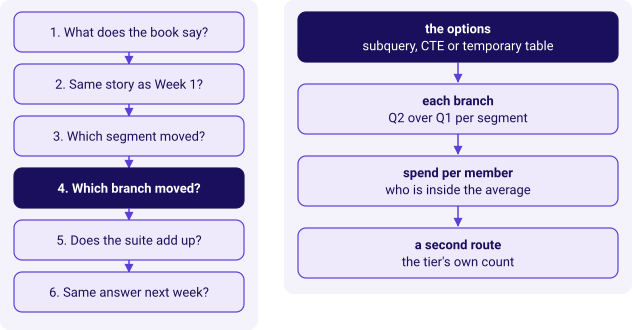

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=3, show=False),
    kit.vflow(['the options\nsubquery, CTE or temporary table', 'each branch\nQ2 over Q1 per segment', 'spend per member\nwho is inside the average', "a second route\nthe tier's own count"], lit=0, show=False),
)

## The options: nested subqueries, named steps or temporary tables?

The comparison needs the same leaves computed twice, once per quarter, and then set side by
side. Three ways to write it:

| Option | How the analyst reads it | Rows written into the warehouse | What a rerun needs |
|---|---|---|---|
| A. Nested subqueries, each quarter inside the main query | From the innermost bracket outwards | None | The one statement |
| B. CTEs, `WITH book AS (...), q1 AS (...), q2 AS (...)`, each a named step | From the top down, one step at a time, each with its comment | None: Postgres works each step out while the query runs | The one statement |
| C. Temporary tables, one `CREATE TEMP TABLE` per step | Several statements, run in order | One temporary table per step, for the session | Every statement, in the same session, in order |

**Predict before you run.** Option C writes the Q1 leaves into a temporary table. The analyst
opens a new session and reads it. What happens?

- a) The analyst sees the same four rows.
- b) The analyst sees an empty table.
- c) The table does not exist in the analyst's session.
- d) The analyst sees the rows as they stand in the warehouse now.

In [3]:
nested = kit.sql(Q["c4_nested"])
print(Q["c4_temp_step"])
conn = kit.connect()
try:
    kit.sql(Q["c4_temp_step"], conn=conn)
    same_session = kit.sql(Q["c4_temp_read"], conn=conn)
finally:
    conn.close()
with kit.expect_error() as gone:
    kit.sql(Q["c4_temp_read"])
kit.table(["option", "statements to run", "rows written", "a rerun in a new session"],
          [("A. nested subqueries", 1, 0, "works"),
           ("B. CTEs", 1, 0, "works"),
           ("C. temporary tables", 2, len(same_session), gone.name or "works")],
          caption="Sized on this warehouse: the three ways to write the comparison")

-- Option 3, a temporary table: the Q1 leaves written into a table that lives only for this session.
CREATE TEMP TABLE q1_leaves AS
SELECT c.segment, count(DISTINCT o.customer_id) AS customers,
       count(*) AS orders, sum(o.amount) AS revenue
FROM   orders o JOIN customers c USING (customer_id)
WHERE  o.quarter = 'Q1'
GROUP  BY c.segment;


option,statements to run,rows written,a rerun in a new session
A. nested subqueries,1,0,works
B. CTEs,1,0,works
C. temporary tables,2,4,UndefinedTable


**What happened.** The answer is c. In the session that made it, the temporary table held four
rows, one per segment; a new session, which is what the analyst opens, finds no such table and
stops with `UndefinedTable`. Nested subqueries and CTEs are single statements, so the analyst
reruns exactly what the team ran.

**The best-fit call.** Option B, CTEs. The analyst reads the steps in the order they happen,
each with a name and a one-line comment, and one statement reruns anywhere. Postgres computes a
CTE once per run even when two later steps read it, and writes nothing into the warehouse.
**What would change the call:** a step that many queries reuse over millions of rows in one long
session is cheaper as a temporary table, computed once and read many times; that is a
performance choice for the platform team, and Anand's suite is not there.

In [4]:
kit.check("the temporary table answered in its own session", len(same_session) == 4)
kit.check("a new session cannot see it", gone.name == "UndefinedTable", gone.name)
kit.check("the nested version returns one row per segment", len(nested) == 4)

## 1. How did customers, frequency and order value move in each segment?

The CTE version names four steps: `book` looks up each order's segment, `q1` and `q2` compute
each quarter's leaves per segment, and the last step divides Q2 by Q1 for each branch. The tree
says the three branch ratios multiply to the revenue ratio, so the query checks itself.

**Predict before you run.** Which branch fell furthest in Retail-Plus?

- a) Customers who bought.
- b) Orders per customer.
- c) Revenue per order.
- d) All three fell by the same amount.

-- Option 2, named steps: the same comparison as three CTEs, read from the top down.
WITH book AS (      -- step 1: each order with its customer's segment
    SELECT o.order_id, o.customer_id, o.quarter, o.amount, c.segment
    FROM   orders o
    JOIN   customers c USING (customer_id)
),
q1 AS (             -- step 2: the Q1 leaves per segment
    SELECT segment, count(DISTINCT customer_id) AS customers,
           count(*) AS orders, sum(amount) AS revenue
    FROM   book
    WHERE  quarter = 'Q1'
    GROUP  BY segment
),
q2 AS (             -- step 3: the Q2 leaves per segment
    SELECT segment, count(DISTINCT customer_id) AS customers,
           count(*) AS orders, sum(amount) AS revenue
    FROM   book
    WHERE  quarter = 'Q2'
    GROUP  BY segment
)
SELECT segment,                                                  -- step 4: each branch's Q2 over Q1
       round(q2.customers::numeric / q1.customers, 3)                      AS customers_ratio,
       round((q2.orders::numeric / 

segment,customers_ratio,frequency_ratio,order_value_ratio,revenue_ratio
Business,0.972,0.965,1.051,0.986
Retail-Core,0.941,1.03,1.012,0.982
Retail-Plus,0.835,0.78,1.084,0.706
Student,1.333,1.056,0.951,1.339


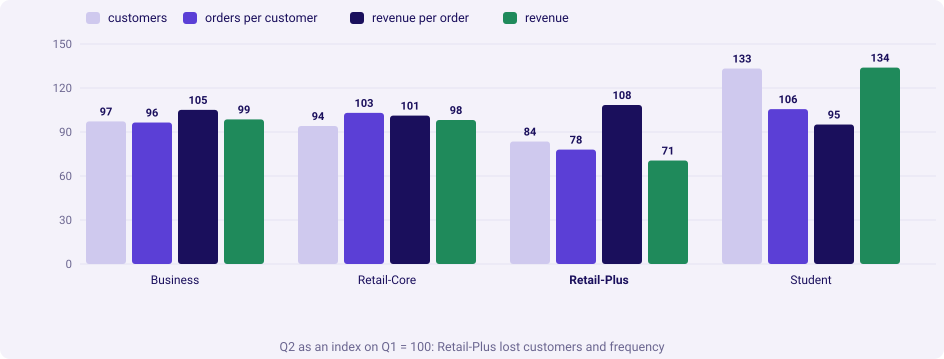

In [5]:
ratios = {r["segment"]: {k: num(v) for k, v in r.items()}
          for r in run("c4_branches", "Each branch as Q2 over Q1, per segment")}
segs = list(ratios)
names = [("customers_ratio", "customers"), ("frequency_ratio", "orders per customer"),
         ("order_value_ratio", "revenue per order"), ("revenue_ratio", "revenue")]
kit.columns(segs, [(label, [round(100 * ratios[s][k], 1) for s in segs]) for k, label in names],
            title="Q2 as an index on Q1 = 100: Retail-Plus lost customers and frequency",
            fmt=lambda v: f"{v:.0f}", lit=(2,))

**What happened.** The answer is b. In Retail-Plus, customers who bought fell to 0.835 of Q1 (91
to 76, down 16.5 percent), orders per customer to 0.780 (down 22.0 percent) and revenue per
order rose to 1.084 (up 8.4 percent); together they multiply to 0.706, the 29.4 percent fall.
Frequency is the branch that fell furthest, and fewer members buying comes second. Business
moved about 3 percent on each branch, and Student grew on customers.

In [6]:
p = ratios["Retail-Plus"]
kit.check("the three branches multiply back to the revenue ratio in every segment",
          all(abs(r["customers_ratio"] * r["frequency_ratio"] * r["order_value_ratio"] - r["revenue_ratio"]) < 0.002
              for r in ratios.values()))
kit.check("in Retail-Plus, frequency fell further than customers",
          p["frequency_ratio"] < p["customers_ratio"], f"{p['frequency_ratio']} against {p['customers_ratio']}")
kit.check("Retail-Plus revenue is 0.706 of Q1", p["revenue_ratio"] == 0.706)

## 2. How much less did each Retail-Plus member spend?

The head of Retail-Plus asks for one number per quarter: the average member's spend. A hurried
analyst builds one row per member with a `CASE` per quarter, `sum(CASE WHEN o.quarter = 'Q1'
THEN o.amount END)`, and averages each column.

**Predict before you run.** How does the average member's spend move from Q1 to Q2?

- a) Down about 15 percent.
- b) Down about 29 percent, as revenue did.
- c) Up, since revenue per order rose.
- d) It cannot be averaged, since some members have no Q2 orders.

In [7]:
hurried = {k: num(v) for k, v in run("c4_member_spend_hurried", "The hurried averages",
                                    money=("q1_average", "q2_average"))[0].items()}
every = {r["segment"]: {k: num(v) for k, v in r.items()}
         for r in kit.sql(Q["c4_every_segment"])}
kit.table(["segment", "Q1 to Q2, the hurried average"],
          [(s, f"{pct(every[s]['q1_skipping'], every[s]['q2_skipping']):+.1f}%") for s in every],
          caption="The same hurried average for every segment")

-- The question: how much did a Retail-Plus member spend in each quarter, on average?
-- (The quickest way to write it.) One row per member who bought in either quarter.
WITH member_spend AS (
    SELECT o.customer_id,
           sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END) AS q1_spend,
           sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  c.segment = 'Retail-Plus'
    GROUP  BY o.customer_id
)
SELECT round(avg(q1_spend)) AS q1_average,
       round(avg(q2_spend)) AS q2_average
FROM   member_spend;


q1_average,q2_average
"Rs 6,437","Rs 5,439"


segment,"Q1 to Q2, the hurried average"
Business,+1.4%
Retail-Core,+4.3%
Retail-Plus,-15.5%
Student,+0.4%


**The plausible wrong answer.** A Retail-Plus member spent Rs 6,437 in Q1 and Rs 5,439 in Q2,
down 15.5 percent, and Retail-Core and Business members each spent more in Q2 than in Q1. The
head of Retail-Plus reads a modest dip and plans a light touch, and the sheet says two segments
grew per member.

**Why it is wrong.** A `CASE` with no `ELSE` gives a missing value, `NULL`, for a member with no
order in that quarter, and `avg` skips missing values without saying so: the PostgreSQL
documentation says `avg` "computes the average (arithmetic mean) of all the non-null input
values". So the Q1 average is over the members who bought in Q1 and the Q2 average over the
members who bought in Q2: two different groups of people. The 31 members who bought in Q1 and
stopped are left out of Q2's average, which is the fall the head of Retail-Plus most needs to
see. The answer the query gave was a; the honest answer is b.

**The check that exposes it.** Count who is inside each average.

-- The check: how many members does the step hold, and how many are inside each average?
WITH member_spend AS (
    SELECT o.customer_id,
           sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END) AS q1_spend,
           sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  c.segment = 'Retail-Plus'
    GROUP  BY o.customer_id
)
SELECT count(*)        AS members_in_the_step,
       count(q1_spend) AS inside_the_q1_average,
       count(q2_spend) AS inside_the_q2_average
FROM   member_spend;


members_in_the_step,inside_the_q1_average,inside_the_q2_average
107,91,76


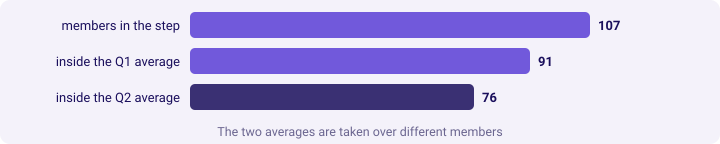

-- The mechanism on three invented values, 100, a missing value and 200. Invented, not Kalpa's data.
SELECT avg(x)              AS average_skipping_null,
       avg(coalesce(x, 0)) AS average_with_zero,
       count(*)            AS rows,
       count(x)            AS values_present
FROM   (VALUES (100), (NULL), (200)) AS invented(x);


average_skipping_null,average_with_zero,rows,values_present
150,100,3,2


[{'average_skipping_null': Decimal('150.0000000000000000'),
  'average_with_zero': Decimal('100.0000000000000000'),
  'rows': 3,
  'values_present': 2}]

In [8]:
who = {k: int(v) for k, v in run("c4_who_is_averaged", "Who is inside each average")[0].items()}
kit.bars([("members in the step", who["members_in_the_step"]),
          ("inside the Q1 average", who["inside_the_q1_average"]),
          ("inside the Q2 average", who["inside_the_q2_average"])],
         title="The two averages are taken over different members", lit=(2,))
run("c4_invented_null", "The mechanism on three invented values: 100, a missing value and 200")

In [9]:
kit.check("the step holds 107 members", who["members_in_the_step"] == 107)
kit.check("the two averages cover different members",
          who["inside_the_q1_average"] != who["inside_the_q2_average"],
          f"{who['inside_the_q1_average']} and {who['inside_the_q2_average']}")

On the three invented values, `avg` returns 150, the mean of the two values present, where 100
is the mean once the missing value is read as zero; `count(*)` sees three rows and `count(x)`
two. The same thing happened to the members: 107 in the step, 91 inside the Q1 average and 76
inside the Q2 average.

**The fix, and what it changed.** A member who bought nothing in a quarter spent Rs 0 in it, so
say so on purpose with `coalesce(..., 0)`, and both averages cover the same 107 members.

-- The fix: a member who bought nothing in a quarter spent Rs 0 there, said on purpose, so both
-- averages cover the same members.
WITH member_spend AS (
    SELECT o.customer_id,
           coalesce(sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END), 0) AS q1_spend,
           coalesce(sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END), 0) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  c.segment = 'Retail-Plus'
    GROUP  BY o.customer_id
)
SELECT count(*)             AS members,
       round(avg(q1_spend)) AS q1_average,
       round(avg(q2_spend)) AS q2_average
FROM   member_spend;


members,q1_average,q2_average
107,"Rs 5,474","Rs 3,863"


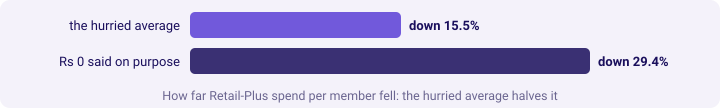

segment,"the hurried average, Q1 to Q2","Rs 0 said on purpose, Q1 to Q2"
Business,+1.4%,-1.4%
Retail-Core,+4.3%,-1.8%
Retail-Plus,-15.5%,-29.4%
Student,+0.4%,+33.9%


Retail-Plus: Rs 5,474 to Rs 3,863, -29.4% over 107 members


In [10]:
fixed = {k: num(v) for k, v in run("c4_member_spend", "The fix: Rs 0 said on purpose",
                                  money=("q1_average", "q2_average"))[0].items()}
kit.bars([("the hurried average", abs(pct(hurried["q1_average"], hurried["q2_average"]))),
          ("Rs 0 said on purpose", abs(pct(fixed["q1_average"], fixed["q2_average"])))],
         fmt=lambda v: f"down {v:.1f}%", lit=(1,),
         title="How far Retail-Plus spend per member fell: the hurried average halves it")
kit.table(["segment", "the hurried average, Q1 to Q2", "Rs 0 said on purpose, Q1 to Q2"],
          [(s, f"{pct(every[s]['q1_skipping'], every[s]['q2_skipping']):+.1f}%",
            f"{pct(every[s]['q1_with_zero'], every[s]['q2_with_zero']):+.1f}%") for s in every],
          caption="Every segment: Retail-Core and Business flip from a rise to a fall")
print(f"Retail-Plus: {kit.rupees(fixed['q1_average'])} to {kit.rupees(fixed['q2_average'])}, "
      f"{pct(fixed['q1_average'], fixed['q2_average']):+.1f}% over {fixed['members']} members")

In [11]:
kit.check("both averages now cover the same 107 members", fixed["members"] == 107)
kit.check("spend per member falls 29.4 percent, as revenue does",
          round(pct(fixed["q1_average"], fixed["q2_average"]), 1) == -29.4)
kit.check("Retail-Core and Business flip from a rise to a fall",
          all(every[s]["q2_skipping"] > every[s]["q1_skipping"] and every[s]["q2_with_zero"] < every[s]["q1_with_zero"]
              for s in ("Retail-Core", "Business")))

**What happened.** Over the same 107 members, a Retail-Plus member spent Rs 5,474 in Q1 and
Rs 3,863 in Q2, down 29.4 percent, twice the hurried 15.5. Retail-Core moves from up 4.3 percent
to down 1.8, and Business from up 1.4 to down 1.4. Only Student rose, by 33.9 percent, on 24
members, which chapter 3 flagged as too few for a rate.

## A second route: does a member count taken from the customer table give the same change?

The first route averaged one row per member built from the orders. The second never averages:
it divides each quarter's Retail-Plus revenue by the tier's members on the customer table,
bought or not, counted in a subquery. Its base is 120 members where the first route's was 107,
so its levels differ, and if both are fair its change must match.

**Predict before you run.** Over the tier's members on the customer table, how does spend per
member move?

- a) Down 15.5 percent.
- b) Down 29.4 percent.
- c) Down more than 29.4 percent, since the base is larger.
- d) It cannot be computed without a join.

-- The second route: Retail-Plus revenue in each quarter over every member on the tier's book,
-- bought or not. The count of members comes from the customer table, in a subquery.
SELECT o.quarter,
       sum(o.amount)                                                     AS revenue,
       (SELECT count(*) FROM customers WHERE segment = 'Retail-Plus')    AS members_on_the_book,
       round(sum(o.amount)
             / (SELECT count(*) FROM customers WHERE segment = 'Retail-Plus')) AS spend_per_member
FROM   orders o
JOIN   customers c USING (customer_id)
WHERE  c.segment = 'Retail-Plus'
GROUP  BY o.quarter
ORDER  BY o.quarter;


quarter,revenue,members_on_the_book,spend_per_member
Q1,"Rs 5,85,770",120,"Rs 4,881"
Q2,"Rs 4,13,380",120,"Rs 3,445"


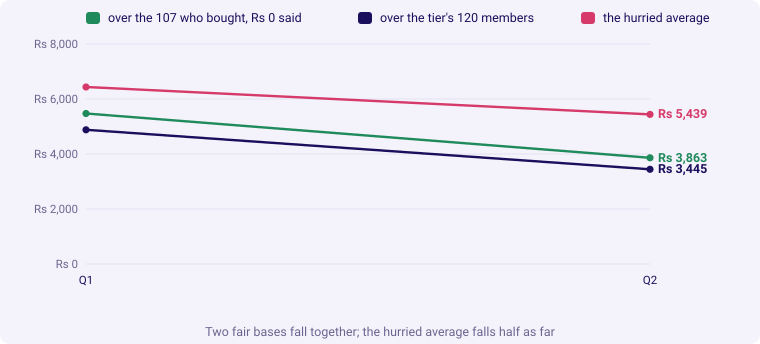

In [12]:
tier = {r["quarter"]: {k: num(v) for k, v in r.items()}
        for r in run("c4_per_member_of_the_tier", "Retail-Plus revenue over every member of the tier",
                     money=("revenue", "spend_per_member"))}
kit.line(["Q1", "Q2"],
         [("over the 107 who bought, Rs 0 said", [fixed["q1_average"], fixed["q2_average"]], "good"),
          ("over the tier's 120 members", [tier["Q1"]["spend_per_member"], tier["Q2"]["spend_per_member"]], "lit"),
          ("the hurried average", [hurried["q1_average"], hurried["q2_average"]], "bad")],
         fmt=lambda v: kit.rupees(v), title="Two fair bases fall together; the hurried average falls half as far")

In [13]:
route2 = pct(tier["Q1"]["spend_per_member"], tier["Q2"]["spend_per_member"])
kit.check("the tier holds 120 members", tier["Q1"]["members_on_the_book"] == 120)
kit.check("the second route falls 29.4 percent, as the fixed average does", round(route2, 1) == -29.4, f"{route2:.1f}%")
kit.check("the product of the branches gives the same fall",
          round(100 * (p["customers_ratio"] * p["frequency_ratio"] * p["order_value_ratio"] - 1), 1) == -29.4)

**What happened.** The answer is b. Over the tier's 120 members, spend per member went from
Rs 4,881 to Rs 3,445, down 29.4 percent: the same change as the fixed average over 107 members,
and the same as the product of the three branches. Any fixed group of members gives the same
change; only an average whose members change between quarters gives a different one.

> **Kavya's review.** An average names who is inside it. Put the zero in on purpose, and write
> the count of members beside the average, so the reader sees that Q1 and Q2 are over the same
> people.

### In the interview: why can an average move when the total does not, and when is a CTE better than a subquery?

**[F] An average moved but the total did not, or moved differently; how?** The denominator
changed. `avg` counts only the rows whose value is present, so if a quarter's missing values
stand for members who bought nothing, those members drop out of that quarter's average. Count
the rows inside the average with `count(column)` beside `count(*)`, decide what a missing value
means, and say it with `coalesce`. Here the Retail-Plus average fell 15.5 percent while revenue
fell 29.4, because 31 members who stopped buying left the Q2 average.

**[F] When would you use a CTE instead of a subquery?** When a step deserves a name, when the
same step is read more than once, or when someone else has to read the query from the top down.
A CTE runs as part of one statement and writes nothing, so an auditor reruns it whole; a
temporary table lives only in the session that made it.

### Depth: why is a quarter with no orders a NULL and not a zero?

`sum` over no rows returns `NULL`, not zero, and a `CASE` with no `ELSE` returns `NULL` for every
row it does not match: "sum of no rows returns null, not zero as one might expect" (PostgreSQL
16 documentation, aggregate functions). A missing value can mean zero, unknown or not
applicable, and SQL cannot tell which, so the query has to say. For spend, a member who bought
nothing spent Rs 0. For a rating, a member who gave none has no rating, and an average that
skips them is right. The habit is the same: decide what the missing value means, and write it.

## What did this chapter answer?

1. **Nested subqueries, named steps or temporary tables?** Named steps, CTEs: one statement the
   analyst reads from the top and reruns anywhere; a temporary table disappeared in a new
   session.
2. **How did each branch move?** In Retail-Plus, customers 0.835, orders per customer 0.780 and
   revenue per order 1.084, which multiply to 0.706: frequency fell furthest, 22.0 percent.
3. **How much less did each Retail-Plus member spend?** Rs 5,474 then Rs 3,863 over the same 107
   members, down 29.4 percent; the average that skipped missing quarters said 15.5 percent.
4. **Does the customer table's count agree?** Yes: Rs 4,881 then Rs 3,445 over the tier's 120
   members, down 29.4 percent, the same change.

Chapter 5 adds the suite's numbers up the way Anand's analyst will.

In [14]:
kit.check_summary()